# Lab 17 — Digital Filters and Multirate Processing

**Companion to Chapter 6** (*Digital Filters and Multirate Processing*).
**Time needed:** about 90 minutes. **Difficulty:** core.

A software radio is mostly filters running at different sample rates. The FPGA in a USRP decimates
61.44 MS/s down to the rate you asked for with CIC and half-band filters; your receiver then mixes,
filters and resamples again. This lab designs FIR and IIR filters, makes decimation and interpolation
efficient with polyphase structures, builds a CIC filter and its compensator, generates carriers with an
NCO, and finally assembles a complete digital down-converter that extracts one channel from a wideband capture.

### What you will learn
1. Design FIR filters by windowing and by Parks–McClellan, and estimate the length a specification needs.
2. Compare Butterworth, Chebyshev and elliptic IIR filters, including their phase/group delay.
3. Implement polyphase decimation and interpolation and verify them against the direct form.
4. Build a multiplier-free CIC decimator and correct its droop.
5. Quantify an NCO's spurs, and build a multi-stage DDC.

### Prerequisites
Lab 1 (complex baseband, the DDC idea). The z-transform and the DFT (Chapter 2). Chapter 6.

### Roadmap
| § | Topic | Interactive |
|---|-------|:-----------:|
| 1 | FIR design: windows versus Parks–McClellan | yes |
| 2 | IIR filters: sharpness versus phase | |
| 3 | Decimation and polyphase filters | |
| 4 | Interpolation | |
| 5 | The CIC filter and its compensator | |
| 6 | The NCO | |
| 7 | A complete multi-stage DDC | |

In [1]:
import os, sys
os.environ.setdefault("OPENBLAS_NUM_THREADS", "2")   # small matrices: avoid BLAS thread thrashing
sys.path[:0] = [p for p in (os.path.abspath(".."), os.path.abspath("."))
                if os.path.isdir(os.path.join(p, "commlib"))]
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sg
import commlib as cl
from commlib import labkit as lk

rng = lk.setup(seed=17, lab="17")

def mag_db(b, a=1.0, n=4096, fs=1.0):
    w, h = sg.freqz(b, a, worN=n, fs=fs)
    return w, lk.db(np.abs(h) ** 2)

Lab 17 ready | numpy 2.5.3 | scipy 1.18.1 | matplotlib 3.11.2 | seed 17


## 1. FIR design: windows versus Parks–McClellan

The **window method** truncates the ideal (sinc) impulse response with a window; the window's sidelobes set
the stop-band attenuation (rectangular ≈ 21 dB, Hamming ≈ 53 dB, Blackman ≈ 74 dB) and its main-lobe width
sets the transition band. The **Kaiser** window has a parameter β that trades the two continuously, and
Kaiser's formula estimates the length for attenuation $A$ (dB) and transition width $\Delta f$ (cycles/sample):
$N \approx (A - 8)/(2.285 \cdot 2\pi\Delta f)$. **Parks–McClellan** (`remez`) designs the *optimal*
equiripple filter for a given length: for the same specification it is typically 10–20% shorter.

### Interactive: a low-pass with cutoff 0.1 (cycles/sample)

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

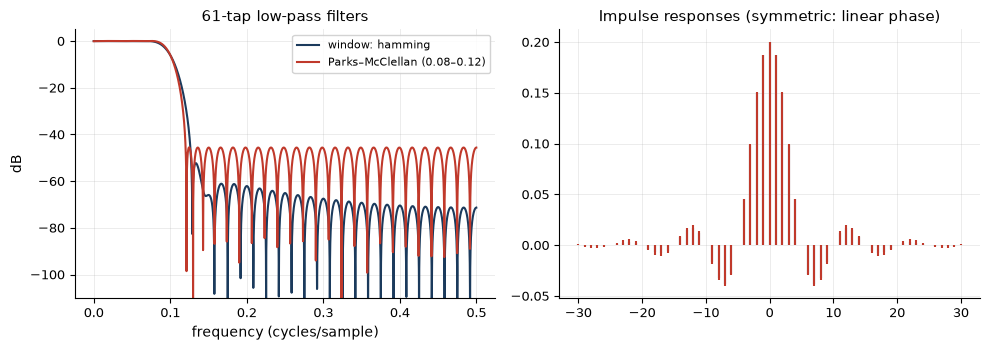

In [3]:
def fir_demo(numtaps=61, window="hamming"):
    f, ax = lk.fig("row2", 1, 2)
    h_w = sg.firwin(numtaps, 0.1, window=window if window != "kaiser (β=6)" else ("kaiser", 6.0), fs=1.0)
    h_r = sg.remez(numtaps, [0, 0.08, 0.12, 0.5], [1, 0], fs=1.0)
    for h_, lab, col in [(h_w, f"window: {window}", lk.NAVY), (h_r, "Parks–McClellan (0.08–0.12)", lk.RED)]:
        w, m = mag_db(h_, fs=1.0)
        ax[0].plot(w, m, color=col, label=lab)
        ax[1].stem(np.arange(numtaps) - numtaps // 2, h_, linefmt=col, markerfmt=" ", basefmt=" ")
    ax[0].set_ylim(-110, 5); ax[0].set_xlabel("frequency (cycles/sample)"); ax[0].set_ylabel("dB"); ax[0].legend(fontsize=8)
    ax[0].set_title(f"{numtaps}-tap low-pass filters"); ax[1].set_title("Impulse responses (symmetric: linear phase)")
    lk.show(f)

lk.interact(fir_demo, numtaps=lk.islider(61, 11, 201, 2, "taps"),
            window=lk.choice(["boxcar", "hamming", "blackman", "kaiser (β=6)"], "hamming", "window"))

**What you should see.** The Hamming design has a deep stop band beyond ~0.13 with decreasing sidelobes; the
Parks–McClellan design has a flat (equiripple) stop band and the specified transition band. Try `boxcar`: the
21 dB first sidelobe (Gibbs phenomenon) does not improve with length.

### Try it yourself 1.1
Use `scipy.signal.kaiserord(ripple, width)` (width as a fraction of the Nyquist rate) to find the number of taps
a Kaiser-window low-pass needs for 80 dB attenuation and a transition band 0.02 cycles/sample wide.

In [5]:
answer_1_1 = None
lk.check("1.1 Kaiser length for 80 dB, Δf = 0.02", answer_1_1, sg.kaiserord(80, 0.02 / 0.5)[0], atol=2)

[TODO] 1.1 Kaiser length for 80 dB, Δf = 0.02: not attempted yet: replace the None with your answer

## 2. IIR filters: sharpness versus phase

Recursive (IIR) filters get much sharper responses from few coefficients, at the price of non-linear phase.
For the same order: **Butterworth** is maximally flat, **Chebyshev I** ripples in the pass band for a steeper
skirt, and **elliptic** (Cauer) ripples in both bands for the steepest possible transition. The group delay
$-d\phi/d\omega$ shows the phase distortion: it peaks near the band edge, which smears pulses (bad for data,
often acceptable for audio).

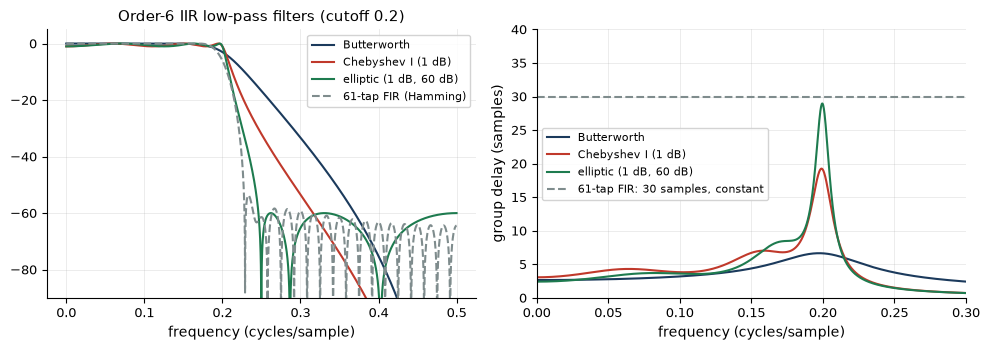

In [7]:
order = 6
designs = {"Butterworth": sg.butter(order, 0.2, fs=1.0),
           "Chebyshev I (1 dB)": sg.cheby1(order, 1, 0.2, fs=1.0),
           "elliptic (1 dB, 60 dB)": sg.ellip(order, 1, 60, 0.2, fs=1.0)}
f, ax = lk.fig("row2", 1, 2)
for name, (b, a) in designs.items():
    w, m = mag_db(b, a)
    ax[0].plot(w, m, label=name)
    wg, gd = sg.group_delay((b, a), w=2048, fs=1.0)
    ax[1].plot(wg, gd, label=name)
h61 = sg.firwin(61, 0.2, fs=1.0)
ax[0].plot(*mag_db(h61), color=lk.GRAY, ls="--", label="61-tap FIR (Hamming)")
ax[1].axhline(30, color=lk.GRAY, ls="--", label="61-tap FIR: 30 samples, constant")
ax[0].set_ylim(-90, 5); ax[0].set_xlabel("frequency (cycles/sample)"); ax[0].legend(fontsize=8)
ax[0].set_title(f"Order-{order} IIR low-pass filters (cutoff 0.2)")
ax[1].set_xlim(0, 0.3); ax[1].set_ylim(0, 40); ax[1].set_xlabel("frequency (cycles/sample)")
ax[1].set_ylabel("group delay (samples)"); ax[1].legend(fontsize=8)
lk.show(f)

**What you should see.** With only 6 poles the elliptic filter is 60 dB down by about 0.25, close to a 61-tap FIR,
but all three IIR designs have group delay that rises sharply near the cutoff, while the symmetric FIR has a
perfectly constant 30-sample delay.

## 3. Decimation and polyphase filters

To reduce the rate by $M$, filter to $\pi/M$ and keep every $M$-th sample. Downsampling without the filter folds
everything above the new Nyquist frequency on top of the wanted band. Computing filter outputs that are then
thrown away is wasteful: the **polyphase** form splits the filter $h$ into $M$ sub-filters
$h_k[n] = h[nM + k]$, each running at the *low* rate on one of $M$ interleaved input streams, and sums them. Same
output, $M$ times fewer multiplications.

"polyphase decimation by 8, 127 taps",
max |difference|,7.77e-16
multiplies per output (direct),1016
multiplies per output (polyphase),127


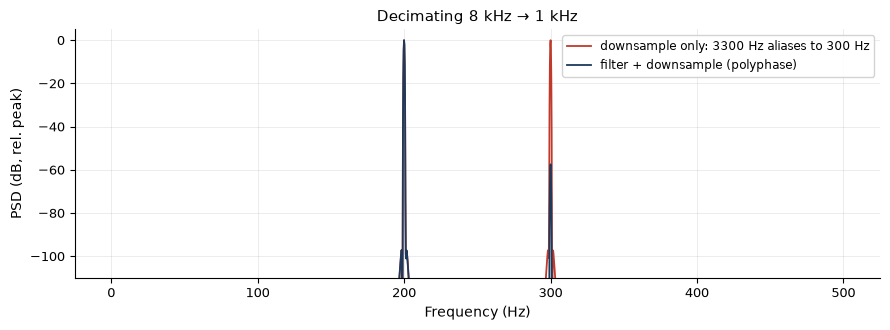

In [10]:
def polyphase_decimate(x, h, M):
    """y[n] = sum_k h[k] x[nM - k], computed with M sub-filters at the low rate."""
    L = int(np.ceil(len(h) / M)) * M
    hp = np.r_[h, np.zeros(L - len(h))].reshape(-1, M).T          # hp[k] = h[k::M]
    xp = np.r_[x, np.zeros((-len(x)) % M)]
    n_out = len(xp) // M
    y = np.zeros(n_out + hp.shape[1], dtype=np.result_type(x, h))
    for k in range(M):
        xk = np.r_[np.zeros(k), xp][::M][:n_out] if k else xp[::M][:n_out]   # x[nM - k]
        y[:n_out + hp.shape[1] - 1] += np.convolve(xk, hp[k])
    return y

M = 8
h_dec = sg.remez(127, [0, 0.4 / M, 0.6 / M, 0.5], [1, 0], fs=1.0)
x = rng.standard_normal(1 << 17)
y_direct = np.convolve(x, h_dec)[::M]          # compute everything, keep every 8th output
y_poly = polyphase_decimate(x, h_dec, M)        # compute only the outputs we keep
n_cmp = len(y_direct) - 20
lk.table([["max |difference|", f"{np.max(np.abs(y_direct[:n_cmp] - y_poly[:n_cmp])):.2e}"],
          ["multiplies per output (direct)", f"{len(h_dec) * M}"], ["multiplies per output (polyphase)", f"{len(h_dec)}"]],
         ["polyphase decimation by 8, 127 taps", ""])

# two tones: one in band, one that would alias without the filter
fsx = 8000.0
tt = np.arange(1 << 15) / fsx
xx = np.sin(2 * np.pi * 200 * tt) + np.sin(2 * np.pi * 3300 * tt)
f, ax = lk.fig("wide")
lk.psd(ax, xx[::M], fsx / M, 4096, label="downsample only: 3300 Hz aliases to 300 Hz", color=lk.RED)
lk.psd(ax, polyphase_decimate(xx, h_dec, M), fsx / M, 4096, label="filter + downsample (polyphase)", color=lk.NAVY)
ax.set_ylim(-110, 5); ax.legend(); ax.set_title("Decimating 8 kHz → 1 kHz")
lk.show(f)

**What you should see.** Bit-exact agreement with the direct form (differences at the $10^{-15}$ level) and an
8-fold reduction in multiplications. Without the filter, the 3.3 kHz tone lands at 300 Hz, indistinguishable from
a real 300 Hz signal.

## 4. Interpolation

To raise the rate by $L$, insert $L-1$ zeros between samples (which creates $L-1$ spectral **images**) and
low-pass filter at $\pi/L$ with gain $L$. Again the polyphase form avoids multiplying by the inserted zeros:
output phase $k$ is the input filtered by $h[nL + k]$. This is exactly how a pulse-shaping filter at $sps$ samples
per symbol is implemented in a modem (Lab 3's exercise).

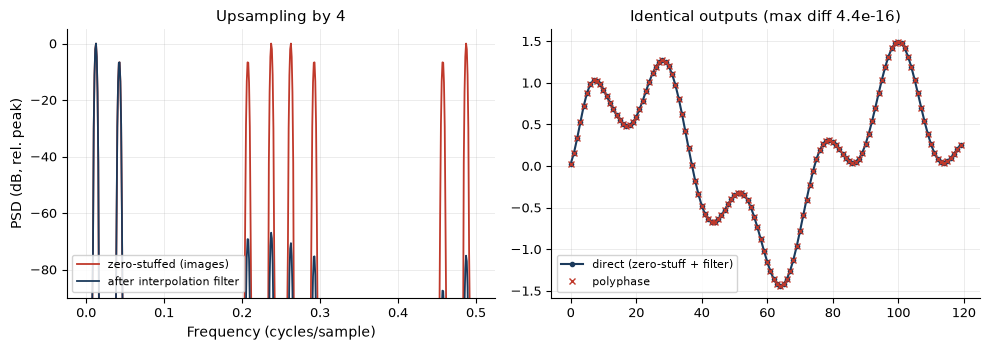

In [13]:
L = 4
h_int = L * sg.firwin(63, 0.5 / L * 0.9 * 2, fs=2.0)
xs = np.sin(2 * np.pi * 0.05 * np.arange(400)) + 0.5 * np.sin(2 * np.pi * 0.17 * np.arange(400))
up = np.zeros(len(xs) * L); up[::L] = xs
y_direct = np.convolve(up, h_int)
phases = [np.convolve(xs, h_int[k::L]) for k in range(L)]
y_poly = np.zeros(max(len(p_) for p_ in phases) * L)
for k, p_ in enumerate(phases):
    y_poly[k:k + len(p_) * L:L] = p_
f, ax = lk.fig("row2", 1, 2)
lk.psd(ax[0], up, 1.0, 1024, label="zero-stuffed (images)", color=lk.RED)
lk.psd(ax[0], y_direct, 1.0, 1024, label="after interpolation filter", color=lk.NAVY)
ax[0].set_ylim(-90, 5); ax[0].legend(fontsize=8); ax[0].set_title("Upsampling by 4")
ax[1].plot(np.arange(120), y_direct[31:151], "o-", ms=3, label="direct (zero-stuff + filter)")
ax[1].plot(np.arange(120), y_poly[31:151], "x", ms=5, color=lk.RED, label="polyphase")
ax[1].legend(fontsize=8); ax[1].set_title(f"Identical outputs (max diff {np.max(np.abs(y_direct[:1500] - y_poly[:1500])):.1e})")
lk.show(f)

## 5. The CIC filter and its compensator

Hogenauer's **cascaded integrator–comb** (CIC) filter decimates by $R$ using only adders: $N$ integrators at the
high rate, downsample, $N$ combs $y[n] = x[n] - x[n-1]$ at the low rate. Its response is
$|H(f)| = \left|\frac{\sin(\pi f R)}{R\sin(\pi f)}\right|^N$: nulls exactly at the frequencies that alias onto DC,
but a **droop** across the pass band. A short FIR **compensator** with an inverse-sinc pass band, running at the
low rate, flattens it. With integer arithmetic the integrators may overflow harmlessly (two's-complement wrap)
as long as the register width is at least $B_{in} + N\log_2 R$ bits. USRP FPGAs use exactly this structure.

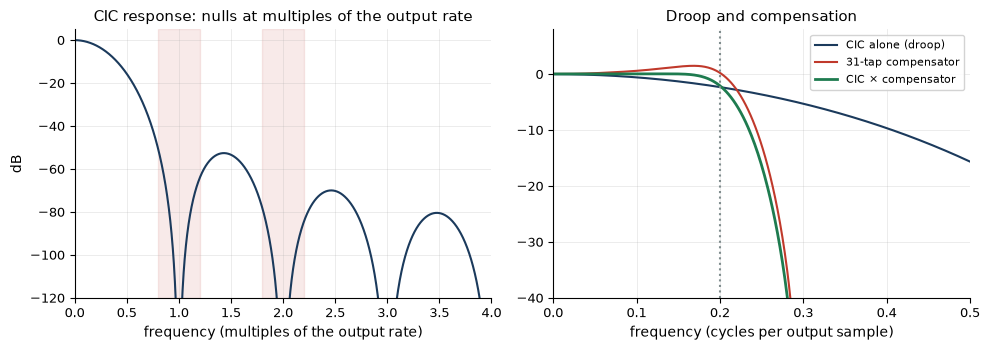

CIC with a constant input of 1000: settled output = 65536000 = 1000 x R^N = 1000 x 65536; register growth N log2 R = 16 bits


In [15]:
def cic_decimate(x_int, R, N):
    """Integer CIC decimator (differential delay 1). Wrap-around arithmetic in int64."""
    y = x_int.astype(np.int64)
    for _ in range(N):
        y = np.cumsum(y)                    # integrators
    y = y[R - 1::R]
    for _ in range(N):
        y = np.diff(y, prepend=0)           # combs
    return y

R, Ncic = 16, 4
fr = np.linspace(1e-6, 0.5, 4000)                      # cycles per *input* sample
H_cic = np.abs(np.sin(np.pi * fr * R) / (R * np.sin(np.pi * fr))) ** Ncic
# measured: impulse response of the CIC = response to a unit impulse
imp = np.zeros(R * 64, dtype=np.int64); imp[0] = 1
# compensation FIR at the low rate: inverse CIC response up to 0.4 of the output Nyquist
fo = np.linspace(0, 0.5, 512)                          # cycles per *output* sample
fo_ = np.maximum(fo, 1e-9)                              # avoid 0/0 at DC (the limit is 1)
cic_at_out = np.abs(np.sin(np.pi * fo_) / (R * np.sin(np.pi * fo_ / R))) ** Ncic
desired = np.where(fo <= 0.2, 1 / cic_at_out, 0.0)
h_comp = sg.firwin2(31, np.r_[fo[fo <= 0.2], 0.25, 0.5] * 2, np.r_[desired[fo <= 0.2], 0, 0], fs=2.0)
_, Hc = sg.freqz(h_comp, worN=fo, fs=1.0)
f, ax = lk.fig("row2", 1, 2)
ax[0].plot(fr * R, lk.db(H_cic ** 2), color=lk.NAVY, label=f"CIC, R = {R}, N = {Ncic}")
ax[0].set_xlim(0, 4); ax[0].set_ylim(-120, 5); ax[0].set_xlabel("frequency (multiples of the output rate)")
ax[0].set_ylabel("dB"); ax[0].set_title("CIC response: nulls at multiples of the output rate")
ax[0].axvspan(0.8, 1.2, color=lk.RED, alpha=0.1); ax[0].axvspan(1.8, 2.2, color=lk.RED, alpha=0.1)
ax[1].plot(fo, lk.db(cic_at_out ** 2), label="CIC alone (droop)")
ax[1].plot(fo, lk.db(np.abs(Hc) ** 2), label="31-tap compensator")
ax[1].plot(fo, lk.db((cic_at_out * np.abs(Hc)) ** 2), lw=2, label="CIC × compensator")
ax[1].set_xlim(0, 0.5); ax[1].set_ylim(-40, 8); ax[1].axvline(0.2, color=lk.GRAY, ls=":")
ax[1].set_xlabel("frequency (cycles per output sample)"); ax[1].legend(fontsize=8); ax[1].set_title("Droop and compensation")
lk.show(f)
y_dc = cic_decimate(np.full(R * 50, 1000, dtype=np.int64), R, Ncic)      # constant input of 1000
print(f"CIC with a constant input of 1000: settled output = {y_dc[-1]} = 1000 x R^N = 1000 x {R ** Ncic}; "
      f"register growth N log2 R = {Ncic * int(np.log2(R))} bits")

**What you should see.** Deep nulls at every multiple of the output rate (the shaded bands are what would alias onto
the pass band). The CIC droops by several dB at 0.2 of the output rate; the compensator lifts it back to within a
fraction of a dB.

### Try it yourself 5.1
How many dB does an R = 16, N = 4 CIC droop at 0.2 cycles per output sample? (Use `cic_at_out`.)

In [17]:
answer_5_1 = None
lk.check("5.1 CIC droop at 0.2 (dB)", answer_5_1, -lk.db(cic_at_out[np.argmin(np.abs(fo - 0.2))] ** 2), atol=0.1)

[TODO] 5.1 CIC droop at 0.2 (dB): not attempted yet: replace the None with your answer

## 6. The NCO

A numerically controlled oscillator is a $W$-bit **phase accumulator** incremented by a tuning word
$\Delta\phi = \mathrm{round}(f/f_s \cdot 2^W)$ (frequency resolution $f_s/2^W$: millihertz for $W = 32$), whose top
$P$ bits address a sine look-up table. Truncating the phase to $P$ bits creates periodic phase errors, hence
**spurs**, about $6.02P$ dB below the carrier. Real DDS chips use phase dithering or larger tables to push them down.

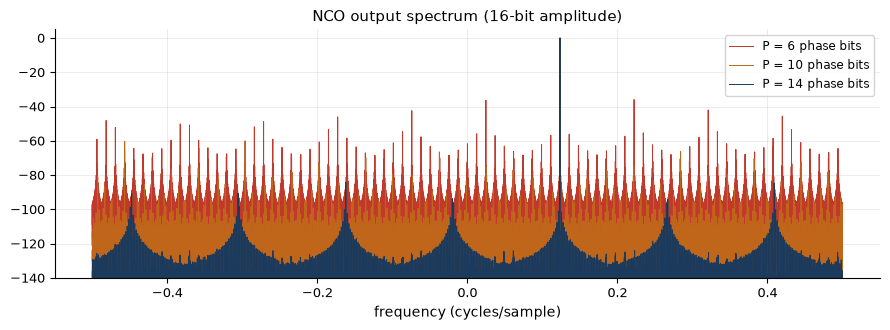

phase bits P,measured SFDR (dB),≈ 6.02 P (dB)
6,35.9,36.1
10,60.1,60.2
14,84.3,84.3


In [19]:
def nco(n, f_norm, W=32, P=10, A=14):
    acc = (np.arange(n, dtype=np.uint64) * np.uint64(round(f_norm * 2 ** W))) % np.uint64(2 ** W)
    idx = (acc >> np.uint64(W - P)).astype(np.int64)
    lut = np.round(np.exp(2j * np.pi * np.arange(2 ** P) / 2 ** P) * (2 ** (A - 1) - 1)) / (2 ** (A - 1) - 1)
    return lut[idx]

f, ax = lk.fig("wide")
rows = []
for P, col in [(6, lk.RED), (10, lk.ORANGE), (14, lk.NAVY)]:
    z = nco(1 << 16, 0.1234567, P=P, A=16)
    Z = np.abs(np.fft.fftshift(np.fft.fft(z * sg.windows.blackmanharris(len(z))))) ** 2
    Zd = lk.db(Z / Z.max())
    ax.plot(np.fft.fftshift(np.fft.fftfreq(len(z))), Zd, color=col, lw=0.7, label=f"P = {P} phase bits")
    pk = int(np.argmax(Z)); mask = np.ones(len(Z), bool); mask[pk - 8:pk + 9] = False
    rows.append([P, -Zd[mask].max(), 6.02 * P])
ax.set_ylim(-140, 5); ax.set_xlabel("frequency (cycles/sample)"); ax.legend(); ax.set_title("NCO output spectrum (16-bit amplitude)")
lk.show(f)
lk.table(rows, ["phase bits P", "measured SFDR (dB)", "≈ 6.02 P (dB)"], fmt={1: ".1f", 2: ".1f"})

**What you should see.** Spurs scattered across the band at roughly 6 dB per phase bit below the carrier; with 14
phase bits the 16-bit amplitude quantization becomes the limit.

## 7. A complete multi-stage DDC

We now extract a 250 kBd QPSK channel at +3.2 MHz from a 16 MS/s capture that also contains two strong
neighbours, and deliver it at 1 MS/s (4 samples/symbol): **NCO** (shift to 0 Hz) → **CIC** (R = 8, N = 4,
multiplier-free, 16 → 2 MS/s) → **compensating FIR decimator** (÷2, 2 → 1 MS/s, done in polyphase form) → RRC
matched filter. This is, stage for stage, the receive chain inside a USRP's FPGA plus the first block of a GNU Radio
flowgraph.

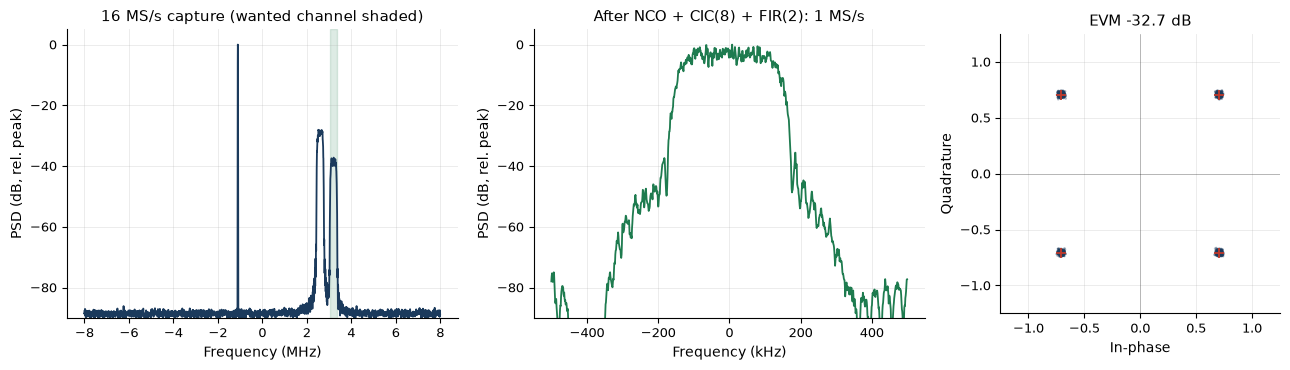

In [22]:
fs_w = 16e6
qpsk = cl.get_constellation("qpsk")
sps_w = 64                                                        # 250 kBd at 16 MS/s
sym = qpsk.modulate(cl.random_bits(2 * 1500, rng))
bb = cl.shape(sym, cl.rrc_taps(0.35, sps_w, 10), sps_w)
n = np.arange(len(bb))
cap = (bb * np.exp(2j * np.pi * 3.2e6 / fs_w * n)
       + 3 * cl.shape(qpsk.modulate(cl.random_bits(2 * 1500, rng)), cl.rrc_taps(0.35, sps_w, 10), sps_w)[:len(n)]
       * np.exp(2j * np.pi * 2.6e6 / fs_w * n)
       + 2 * np.exp(2j * np.pi * -1.1e6 / fs_w * n))
cap = cap + np.sqrt(1e-5 / 2) * (rng.standard_normal(len(n)) + 1j * rng.standard_normal(len(n)))
# stage 1: NCO mix
mixed = cap * np.conj(nco(len(n), 3.2e6 / fs_w, P=14, A=16))
# stage 2: CIC R = 8, N = 4 on fixed-point I and Q (16-bit input scaling)
scale = 2 ** 13
cic_out = (cic_decimate(np.round(mixed.real * scale).astype(np.int64), 8, 4)
           + 1j * cic_decimate(np.round(mixed.imag * scale).astype(np.int64), 8, 4)) / (scale * 8 ** 4)
# stage 3: compensating half-rate FIR, decimate by 2 (polyphase)
fo2 = np.linspace(0, 0.5, 256)                                    # cycles per CIC-output sample (2 MS/s)
fo2_ = np.maximum(fo2, 1e-9)
cic2 = np.abs(np.sin(np.pi * fo2_) / (8 * np.sin(np.pi * fo2_ / 8))) ** 4
pb = fo2 <= 0.09                                                  # 180 kHz of 2 MS/s: covers 0.675 x 250 kHz
h_c2 = sg.firwin2(63, np.r_[fo2[pb], 0.16, 0.5] * 2, np.r_[1 / cic2[pb], 0, 0], fs=2.0)
y1 = polyphase_decimate(cic_out, h_c2, 2)
# stage 4: matched filter at 4 samples/symbol and symbol sampling
z = cl.matched_filter(y1, cl.rrc_taps(0.35, 4, 10))
cands = [z[k::4][60:1400] for k in range(4)]
zs = max(cands, key=lambda c: np.mean(np.abs(c) ** 2))
lag = int(np.argmax([np.abs(np.vdot(sym[d_:d_ + 600], zs[:600])) for d_ in range(0, 120)]))
ref = sym[lag:lag + len(zs)]
zs = zs[:len(ref)] * np.vdot(zs[:len(ref)], ref) / np.vdot(zs[:len(ref)], zs[:len(ref)])
f, ax = lk.fig((13, 3.8), 1, 3, gridspec_kw={"width_ratios": [1.4, 1.4, 1]})
lk.psd(ax[0], cap, fs_w, 4096, scale=1e6, unit="MHz"); ax[0].axvspan(3.05, 3.35, color=lk.GREEN, alpha=0.15)
ax[0].set_ylim(-90, 5); ax[0].set_title("16 MS/s capture (wanted channel shaded)")
lk.psd(ax[1], y1, 1e6, 1024, scale=1e3, unit="kHz", color=lk.GREEN); ax[1].set_ylim(-90, 5)
ax[1].set_title("After NCO + CIC(8) + FIR(2): 1 MS/s")
lk.constellation(ax[2], zs, qpsk.points, f"EVM {lk.db(np.mean(np.abs(zs - ref) ** 2)):.1f} dB")
lk.show(f)

**What you should see.** The strong neighbour 600 kHz below and the carrier at −1.1 MHz are gone after the DDC;
the wanted channel sits at 0 Hz with its RRC shape intact, and the constellation is clean (EVM around −30 dB,
limited by the short filters and fixed-point arithmetic, not by the neighbours).

## Key takeaways
* FIR filters: linear phase, length set by attenuation and transition width (Kaiser's formula); Parks–McClellan is optimal.
* IIR filters: far fewer coefficients for a sharp skirt, but non-linear phase.
* Polyphase decimators and interpolators compute only the outputs you keep: $M$ times cheaper.
* CIC filters decimate with adders only; their droop needs a small compensator; register growth is $N\log_2R$ bits.
* NCO spurs fall about 6 dB per phase bit. A DDC chains NCO → CIC → FIR decimators → matched filter.

## Going further (hardware: USRP B200 / GNU Radio)
* The B200 FPGA's DDC uses a CIC followed by half-band filters; request an odd decimation (e.g. 61.44/5 MS/s) and
  look at the passband ripple and droop of the captured noise floor with gr01.
* GNU Radio's `Frequency Xlating FIR Filter` and `Rational Resampler` blocks implement Sections 3, 4 and 7; build
  the same DDC as a flowgraph and compare CPU load with and without the polyphase form (`Polyphase Decimator`).

## Exercises
1. **(Warm-up)** Show that a CIC with N = 1 is a moving-average filter of length R followed by decimation.
2. **(Core)** Design a half-band filter (every other tap zero except the centre) with `remez` and use two of them to
   decimate by 4. Count multiplies per output and compare with a single FIR.
3. **(Core)** Add phase dithering to the NCO (a random LSB added to the accumulator before truncation) and show that
   the spurs turn into a noise floor.
4. **(Stretch)** Implement a Farrow fractional resampler (cubic Lagrange, as in `cl.interp_cubic`) and convert
   1 MS/s to 44.1/48 of that rate; measure the image rejection.

In [25]:
lk.summary()

[good] Lab 17 finished in 2.0 s. Self-checks: 0 passed, 0 failed, 2 still to do.